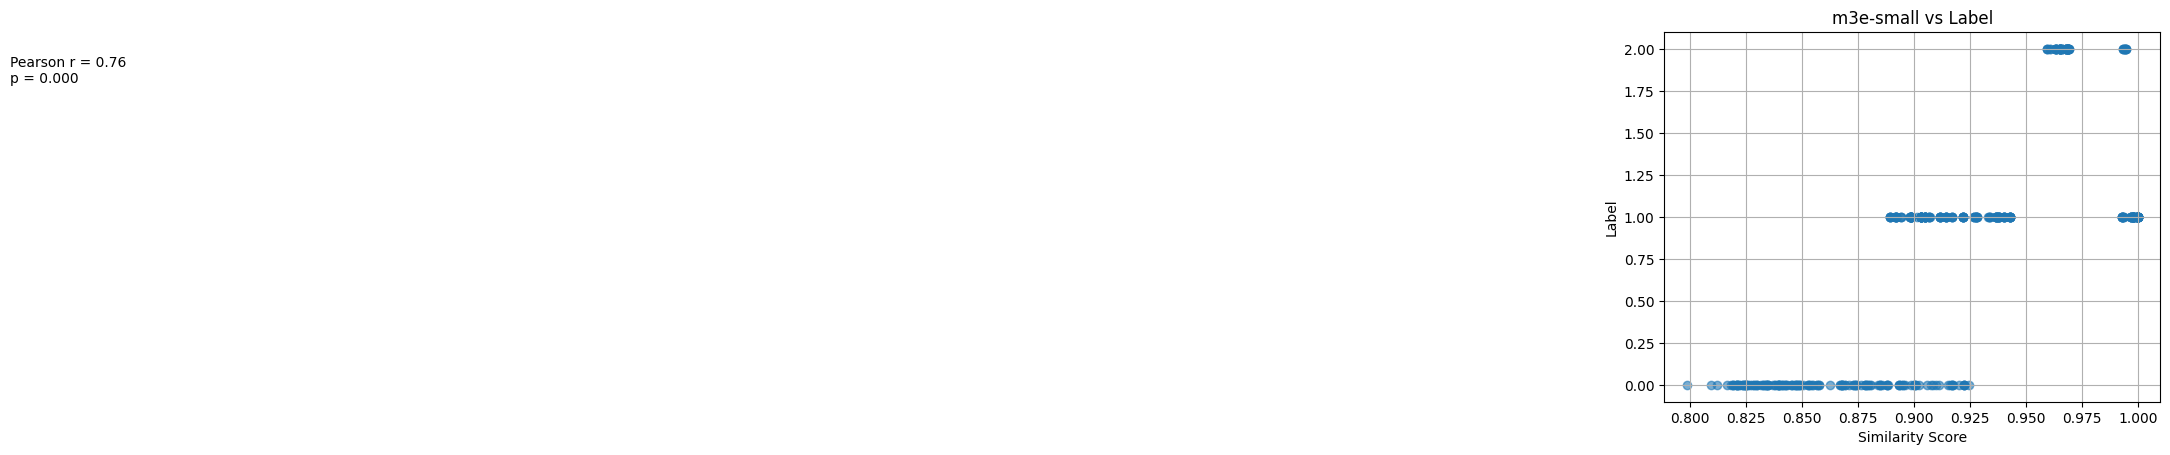

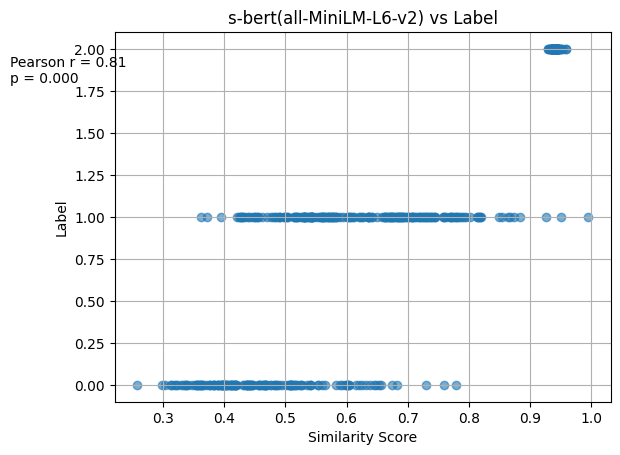

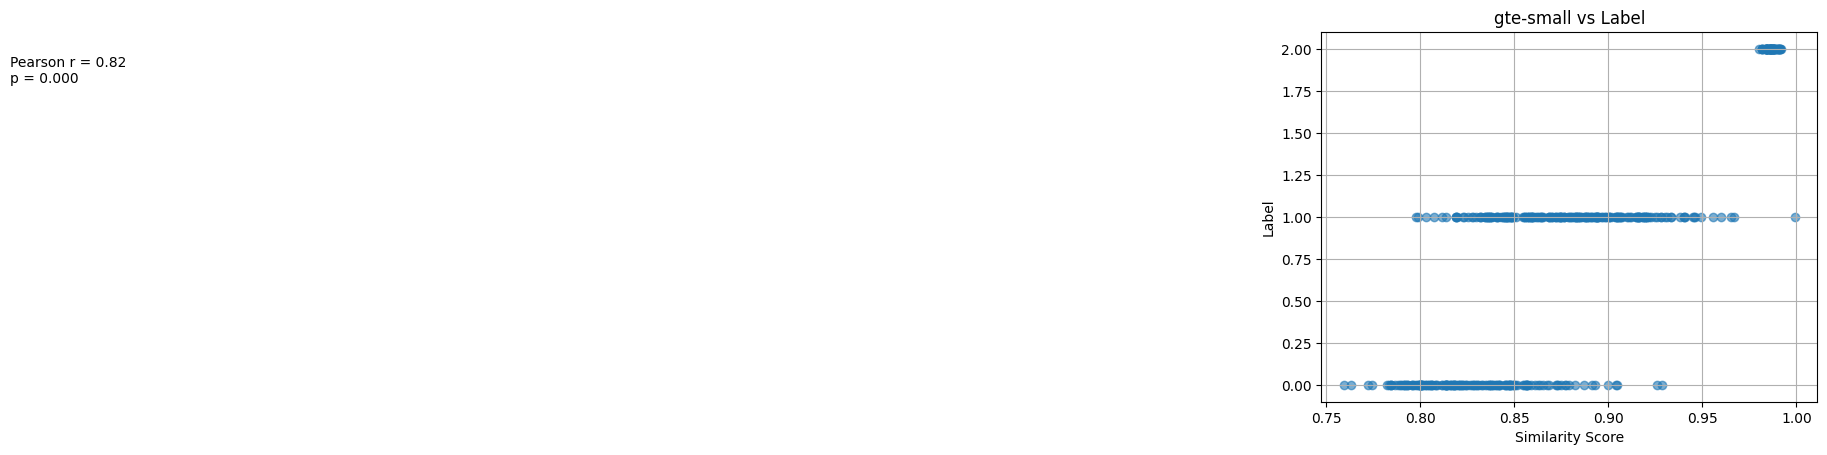

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 读取CSV文件
file_path = "副本8.7数据结果.csv"  # 修改为你本地文件的实际路径
df = pd.read_csv(file_path)

# 转换为数值类型
df["label"] = pd.to_numeric(df["label"], errors="coerce")
df["m3e-small"] = pd.to_numeric(df["m3e-small"], errors="coerce")
df["s-bert(all-MiniLM-L6-v2)"] = pd.to_numeric(df["s-bert(all-MiniLM-L6-v2)"], errors="coerce")
df["gte-small"] = pd.to_numeric(df["gte-small"], errors="coerce")

# 模型名称列表
models = ["m3e-small", "s-bert(all-MiniLM-L6-v2)", "gte-small"]

# 绘图：x为相似度，y为人工标签
for model in models:
    plt.figure()
    plt.scatter(df[model], df["label"], alpha=0.6)
    plt.title(f"{model} vs Label")
    plt.xlabel("Similarity Score")
    plt.ylabel("Label")
    
    # 计算皮尔逊相关系数
    corr, p_value = pearsonr(df[model], df["label"])
    plt.text(0.05, 1.8, f"Pearson r = {corr:.2f}\np = {p_value:.3f}", fontsize=10)
    plt.grid(True)
    plt.show()
